# Options Strategy Simulator — From Legs to Tail Risk

This notebook walks through the full simulation pipeline:

1. **Black-Scholes pricing** — vectorized pricing with dividend yield
2. **SVI volatility smile** — realistic skew and wing pricing
3. **Strategy construction** — multi-leg positions from presets or custom legs
4. **Payoff diagrams** — intrinsic value at expiry with breakeven detection
5. **Portfolio Greeks** — aggregated risk sensitivities across legs
6. **P&L over time** — how theta decay reshapes the payoff
7. **Monte Carlo simulation** — P&L distribution with Student-t fat tails
8. **VRP strategy comparison** — short straddle vs iron butterfly vs broken-wing butterfly

In [1]:
# Colab setup — run this cell if you are on Google Colab
import os
if "COLAB_RELEASE_TAG" in os.environ:
    !git clone --depth 1 https://github.com/louisgay/quant-apps.git /content/quant-apps
    !pip install -q -r /content/quant-apps/options_strategy_simulator/requirements.txt
    os.chdir("/content/quant-apps/options_strategy_simulator")

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sys.path.insert(0, str(Path.cwd()))

from engine import (
    # Pricing
    bs_price, bs_delta, bs_gamma, bs_theta, bs_vega, bs_rho,
    # Volatility
    VolSmile,
    # Strategy
    OptionLeg, Strategy,
    straddle, strangle, bull_call_spread, bear_put_spread,
    butterfly, iron_condor, collar, ratio_spread, calendar_spread,
    # Greeks
    compute_portfolio_greeks, compute_greeks_vs_spot,
    # Analytics
    compute_payoff_diagram, compute_pnl_surface, compute_greeks_over_spot,
    # Monte Carlo
    simulate_strategy,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 11})
print("Engine loaded.")

Engine loaded.


---
## 1. Black-Scholes Pricing

The engine prices each leg with the Black-Scholes formula extended for continuous dividend yield $q$:

$$C = S e^{-qT} \Phi(d_1) - K e^{-rT} \Phi(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

All functions are **vectorized** — pass a scalar or an array and NumPy broadcasting handles the rest.

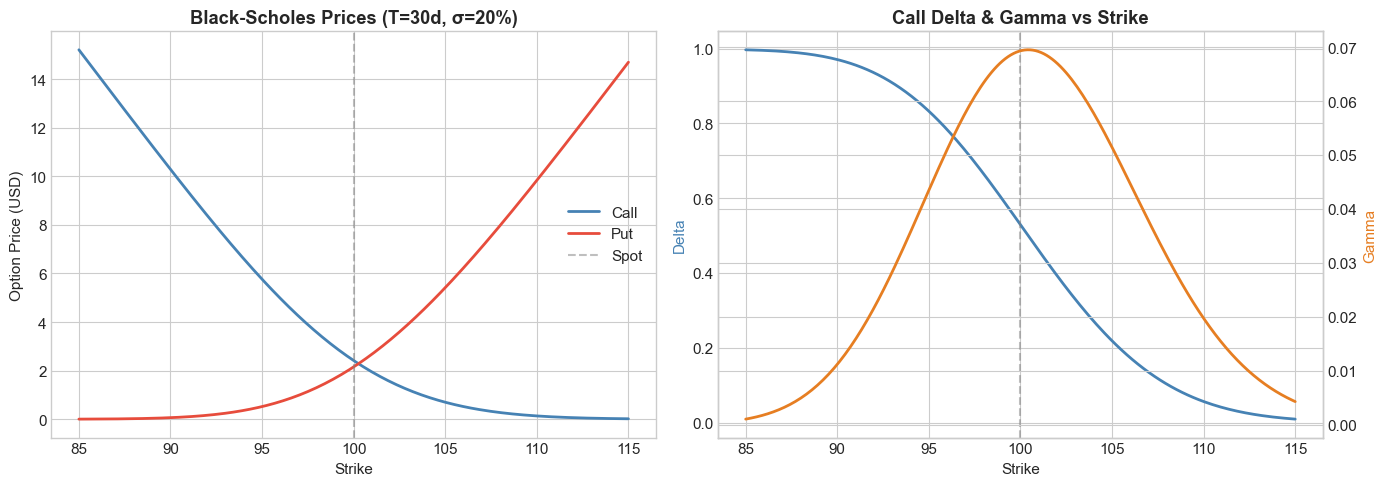

Put-call parity check: C - P = 0.262388, S*exp(-qT) - K*exp(-rT) = 0.262388
Error: 0.00e+00


In [3]:
# Market parameters
S = 100.0   # spot price
r = 0.045   # risk-free rate
q = 0.013   # dividend yield (SPY-like)
T = 30/365  # 30 days to expiry
sigma = 0.20  # 20% ATM vol

# Price a range of strikes in one vectorized call
strikes = np.linspace(85, 115, 200)
call_prices = bs_price(S, strikes, T, r, sigma, option_type="call", q=q)
put_prices = bs_price(S, strikes, T, r, sigma, option_type="put", q=q)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(strikes, call_prices, linewidth=2, color="steelblue", label="Call")
axes[0].plot(strikes, put_prices, linewidth=2, color="#e74c3c", label="Put")
axes[0].axvline(S, color="gray", linestyle="--", alpha=0.5, label="Spot")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("Option Price (USD)")
axes[0].set_title("Black-Scholes Prices (T=30d, \u03c3=20%)", fontweight="bold")
axes[0].legend()

# Greeks across strikes
deltas = bs_delta(S, strikes, T, r, sigma, option_type="call", q=q)
gammas = bs_gamma(S, strikes, T, r, sigma, q=q)

axes[1].plot(strikes, deltas, linewidth=2, color="steelblue", label="Delta")
ax2 = axes[1].twinx()
ax2.plot(strikes, gammas, linewidth=2, color="#e67e22", label="Gamma")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Delta", color="steelblue")
ax2.set_ylabel("Gamma", color="#e67e22")
axes[1].set_title("Call Delta & Gamma vs Strike", fontweight="bold")
axes[1].axvline(S, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Verify put-call parity: C - P = S*exp(-qT) - K*exp(-rT)
K_test = 100.0
c = bs_price(S, K_test, T, r, sigma, option_type="call", q=q)
p = bs_price(S, K_test, T, r, sigma, option_type="put", q=q)
parity_lhs = c - p
parity_rhs = S * np.exp(-q * T) - K_test * np.exp(-r * T)
print(f"Put-call parity check: C - P = {parity_lhs:.6f}, S*exp(-qT) - K*exp(-rT) = {parity_rhs:.6f}")
print(f"Error: {abs(parity_lhs - parity_rhs):.2e}")

---
## 2. SVI Volatility Smile

Real markets don't have flat implied volatility. OTM puts trade at higher IV than ATM options (the **skew**), reflecting crash risk premium and hedging demand.

The engine models this with Gatheral's **SVI** (Stochastic Volatility Inspired) parameterization:

$$w(k) = a + b \left[ \rho(k - m) + \sqrt{(k-m)^2 + \sigma_{\text{svi}}^2} \right]$$

where $w = \sigma^2 T$ is total implied variance and $k = \ln(K/S)$ is log-moneyness.

We provide a **simple mode** with three intuitive sliders:
- **ATM vol**: sets the level
- **Skew** (0–1): how much more expensive OTM puts are
- **Curvature** (0–2): how steep the wings are on both sides

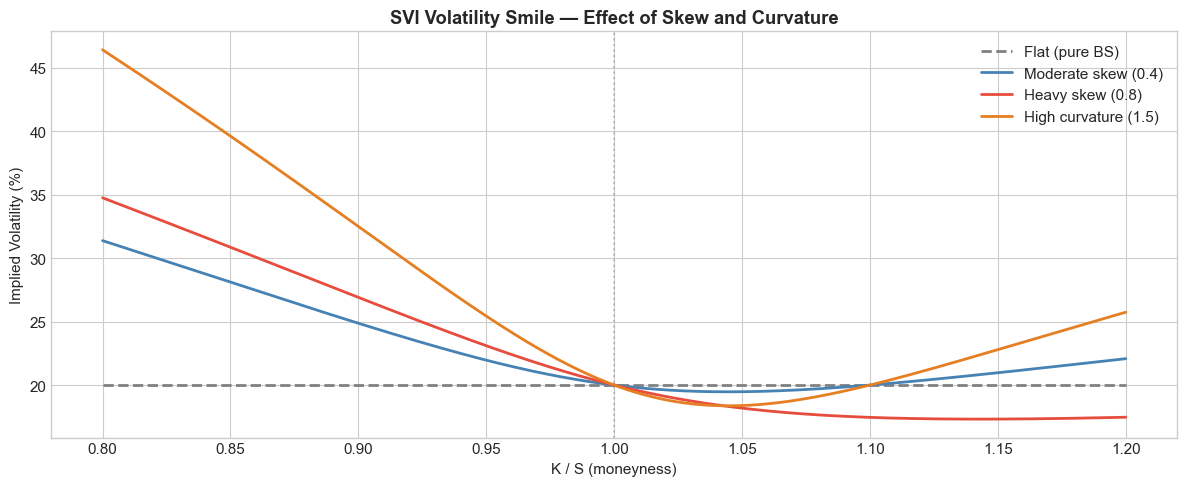

OTM Put (K=92):
  Flat IV: 20.0%  =>  Price: $0.1607
  Skewed IV: 24.5%  =>  Price: $0.3587
  Skew premium: $0.1979 (123.2% more expensive)


In [4]:
strikes_pct = np.linspace(0.80, 1.20, 300) * S  # 80% to 120% of spot

# Compare flat vs skewed vs high-curvature smiles
smiles = {
    "Flat (pure BS)": VolSmile.flat(0.20),
    "Moderate skew (0.4)": VolSmile.from_simple(0.20, skew=0.4, curvature=0.5),
    "Heavy skew (0.8)": VolSmile.from_simple(0.20, skew=0.8, curvature=0.5),
    "High curvature (1.5)": VolSmile.from_simple(0.20, skew=0.4, curvature=1.5),
}

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["gray", "steelblue", "#e74c3c", "#e67e22"]

for (name, smile), color in zip(smiles.items(), colors):
    ivs = smile.get_iv_for_strike(strikes_pct, S, T) * 100
    linestyle = "--" if name.startswith("Flat") else "-"
    ax.plot(strikes_pct / S, ivs, linewidth=2, color=color, linestyle=linestyle, label=name)

ax.axvline(1.0, color="gray", linestyle=":", alpha=0.4)
ax.set_xlabel("K / S (moneyness)")
ax.set_ylabel("Implied Volatility (%)")
ax.set_title("SVI Volatility Smile \u2014 Effect of Skew and Curvature", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Show how skew affects option prices
smile_flat = VolSmile.flat(0.20)
smile_skew = VolSmile.from_simple(0.20, skew=0.6, curvature=0.5)

K_otm_put = 92.0
iv_flat = smile_flat.get_iv_for_strike(K_otm_put, S, T)
iv_skew = smile_skew.get_iv_for_strike(K_otm_put, S, T)
price_flat = bs_price(S, K_otm_put, T, r, float(iv_flat), option_type="put", q=q)
price_skew = bs_price(S, K_otm_put, T, r, float(iv_skew), option_type="put", q=q)

print(f"OTM Put (K=92):")
print(f"  Flat IV: {iv_flat*100:.1f}%  =>  Price: ${price_flat:.4f}")
print(f"  Skewed IV: {iv_skew*100:.1f}%  =>  Price: ${price_skew:.4f}")
print(f"  Skew premium: ${price_skew - price_flat:.4f} ({(price_skew/price_flat - 1)*100:.1f}% more expensive)")

---
## 3. Building Strategies

A strategy is a list of `OptionLeg` objects. Each leg has a type (call/put), direction (long/short), strike, expiry, and quantity.

Nine presets are available, or you can build custom positions leg by leg.

In [5]:
T_30d = 30 / 365

strategies = {
    "Long Straddle": straddle(100, T_30d),
    "Iron Condor": iron_condor(90, 95, 105, 110, T_30d),
    "Butterfly": butterfly(95, 100, 105, T_30d),
    "Bull Call Spread": bull_call_spread(98, 105, T_30d),
}

smile = VolSmile.from_simple(0.20, skew=0.4, curvature=0.5)

# Print structure and entry cost for each
for name, strat in strategies.items():
    cost = strat.compute_entry_cost(S, r, q, smile)
    print(f"\n{name} ({len(strat.legs)} legs):")
    for leg in strat.legs:
        iv = smile.get_iv_for_strike(leg.strike, S, leg.T)
        price = bs_price(S, leg.strike, leg.T, r, float(iv), leg.option_type, q)
        sign = "+" if leg.direction == "long" else "-"
        print(f"  {sign}{leg.quantity} {leg.option_type.upper()} K={leg.strike}  "
              f"IV={iv*100:.1f}%  Price=${price:.2f}")
    debit_credit = "DEBIT" if cost > 0 else "CREDIT"
    print(f"  Net entry: ${cost:.2f} ({debit_credit})")


Long Straddle (2 legs):
  +1 CALL K=100  IV=20.0%  Price=$2.42
  +1 PUT K=100  IV=20.0%  Price=$2.15
  Net entry: $4.57 (DEBIT)

Iron Condor (4 legs):
  -1 PUT K=95  IV=22.0%  Price=$0.67
  +1 PUT K=90  IV=24.9%  Price=$0.19
  -1 CALL K=105  IV=19.5%  Price=$0.65
  +1 CALL K=110  IV=20.0%  Price=$0.13
  Net entry: $-0.99 (CREDIT)

Butterfly (3 legs):
  +1 CALL K=95  IV=22.0%  Price=$5.91
  -2 CALL K=100  IV=20.0%  Price=$2.42
  +1 CALL K=105  IV=19.5%  Price=$0.65
  Net entry: $1.73 (DEBIT)

Bull Call Spread (2 legs):
  +1 CALL K=98  IV=20.6%  Price=$3.63
  -1 CALL K=105  IV=19.5%  Price=$0.65
  Net entry: $2.97 (DEBIT)


---
## 4. Payoff Diagrams

The payoff at expiry is the intrinsic value of the position minus the entry cost:

$$\text{P\&L}(S_T) = \sum_{i} \text{sign}_i \cdot q_i \cdot \max(0,\, \phi_i(S_T - K_i)) - \text{Entry Cost}$$

where $\phi_i = +1$ for calls and $-1$ for puts.

**Breakeven points** are found via linear interpolation where the P&L crosses zero.

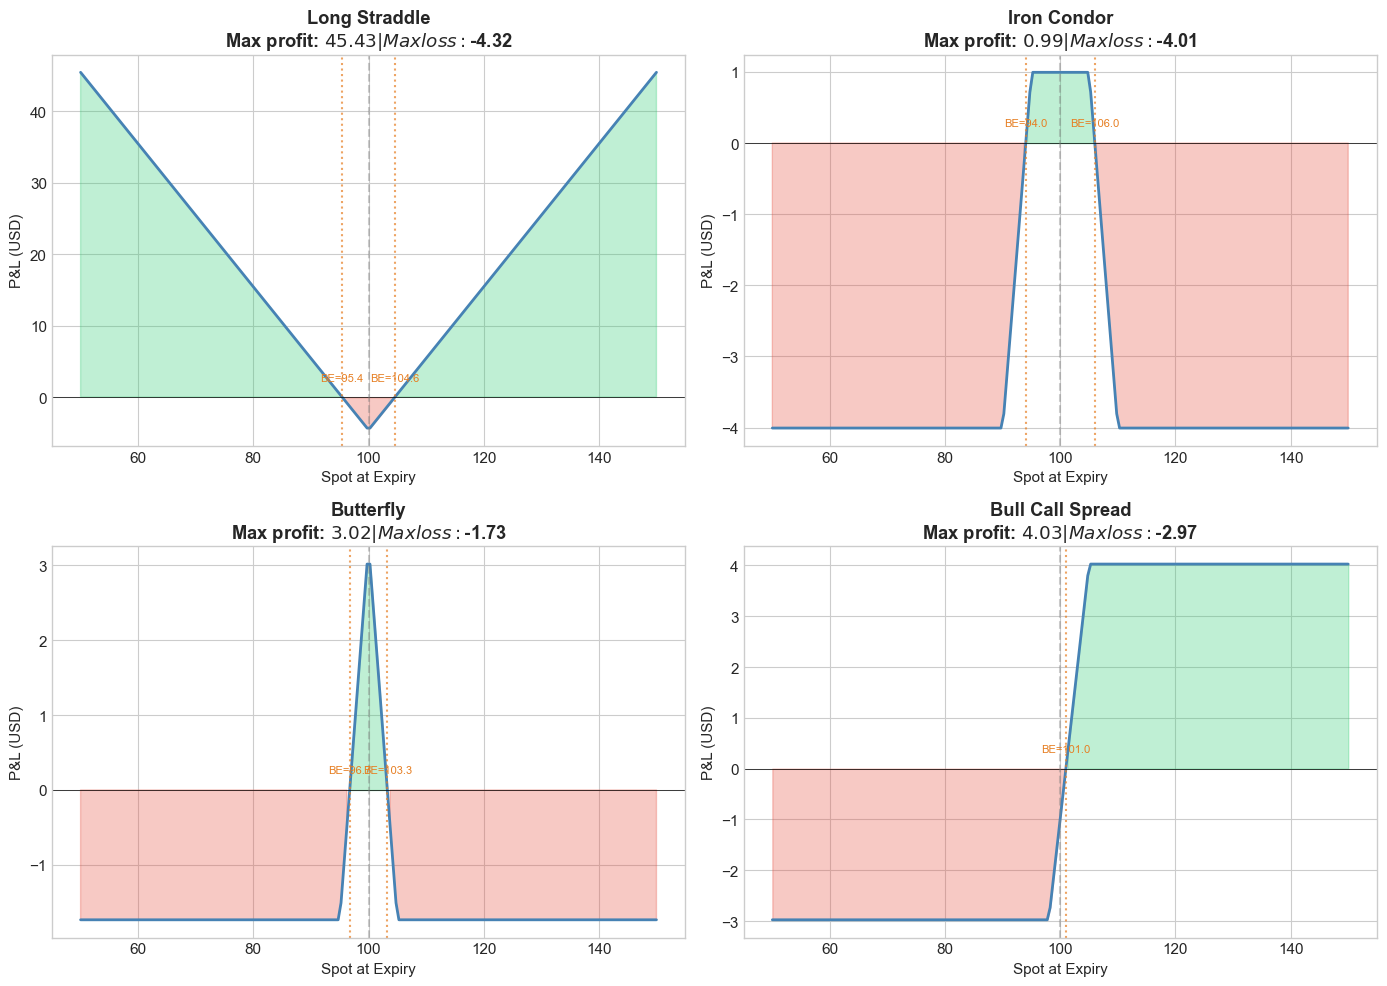

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for (name, strat), ax in zip(strategies.items(), axes.flat):
    result = compute_payoff_diagram(strat, S, r, q, smile)

    # P&L line
    ax.plot(result.S_range, result.pnl_at_expiry, linewidth=2, color="steelblue")
    ax.fill_between(result.S_range, result.pnl_at_expiry, 0,
                    where=result.pnl_at_expiry > 0, color="#2ecc71", alpha=0.3)
    ax.fill_between(result.S_range, result.pnl_at_expiry, 0,
                    where=result.pnl_at_expiry < 0, color="#e74c3c", alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.axvline(S, color="gray", linestyle="--", alpha=0.4)

    # Breakeven markers
    for be in result.breakeven_points:
        ax.axvline(be, color="#e67e22", linestyle=":", alpha=0.7)
        ax.annotate(f"BE={be:.1f}", xy=(be, 0), xytext=(0, 12),
                    textcoords="offset points", fontsize=8, color="#e67e22",
                    ha="center")

    max_p = f"${result.max_profit:.2f}" if np.isfinite(result.max_profit) else "Unlimited"
    max_l = f"${result.max_loss:.2f}" if np.isfinite(result.max_loss) else "Unlimited"
    ax.set_title(f"{name}\nMax profit: {max_p}  |  Max loss: {max_l}", fontweight="bold")
    ax.set_xlabel("Spot at Expiry")
    ax.set_ylabel("P&L (USD)")

plt.tight_layout()
plt.show()

---
## 5. Portfolio Greeks

Greeks are computed analytically per leg using Black-Scholes, then aggregated:

$$\Delta_{\text{portfolio}} = \sum_i \text{sign}_i \cdot q_i \cdot \Delta_i(S, K_i, T_i, r, \sigma_i)$$

The skew-adjusted IV $\sigma_i$ is looked up from the smile for each leg's strike. This matters — a short iron condor's put wing has a higher IV than the call wing, so the net delta and vega are asymmetric.

In [7]:
# Greeks summary table
rows = []
for name, strat in strategies.items():
    g = compute_portfolio_greeks(strat, S, r, q, smile)
    rows.append({
        "Strategy": name,
        "Delta": f"{g.delta:+.4f}",
        "Gamma": f"{g.gamma:+.4f}",
        "Theta/day": f"${g.theta_daily:+.2f}",
        "Vega": f"{g.vega:+.4f}",
        "Rho": f"{g.rho:+.4f}",
    })

df_greeks = pd.DataFrame(rows)
display(df_greeks)

print("\nInterpretation:")
print("- Long Straddle: near-zero delta (direction-neutral), positive gamma and vega (wants movement and vol)")
print("- Iron Condor: short gamma/vega (wants no movement), collects theta")
print("- Butterfly: similar to iron condor but more concentrated around center strike")
print("- Bull Call Spread: positive delta (bullish), moderate theta drag")

,Strategy,Delta,Gamma,Theta/day,Vega,Rho
0,Long Straddle,+0.0594,+0.1386,$-0.08,+22.7868,+0.1124
1,Iron Condor,-0.0293,-0.0580,$+0.03,-9.3320,-0.1588
2,Butterfly,-0.0344,-0.0441,$+0.02,-6.7793,-0.4255
3,Bull Call Spread,+0.4485,+0.0100,$-0.01,+2.1742,+3.4419



Interpretation:
- Long Straddle: near-zero delta (direction-neutral), positive gamma and vega (wants movement and vol)
- Iron Condor: short gamma/vega (wants no movement), collects theta
- Butterfly: similar to iron condor but more concentrated around center strike
- Bull Call Spread: positive delta (bullish), moderate theta drag


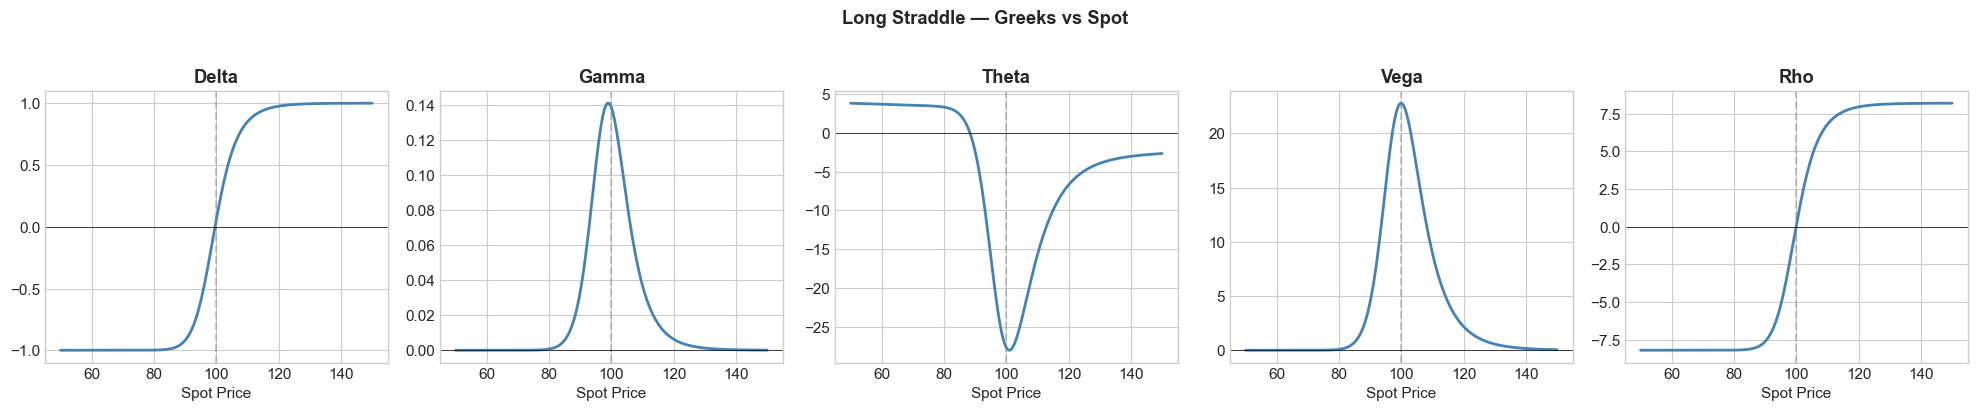

In [8]:
# Greeks vs spot for a long straddle
strat = straddle(100, T_30d)
greeks_grid = compute_greeks_over_spot(strat, S, r, q, smile)

greek_names = ["delta", "gamma", "theta", "vega", "rho"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, name in zip(axes, greek_names):
    values = getattr(greeks_grid, name)
    ax.plot(greeks_grid.x_values, values, linewidth=2, color="steelblue")
    ax.axvline(S, color="gray", linestyle="--", alpha=0.4)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(name.capitalize(), fontweight="bold")
    ax.set_xlabel(greeks_grid.x_label)

fig.suptitle("Long Straddle — Greeks vs Spot", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 6. P&L Over Time

At expiry, P&L is the hockey-stick payoff. Before expiry, options retain **time value**, computed via full Black-Scholes repricing (not linear interpolation). This shows how theta decay reshapes the payoff curve as expiry approaches.

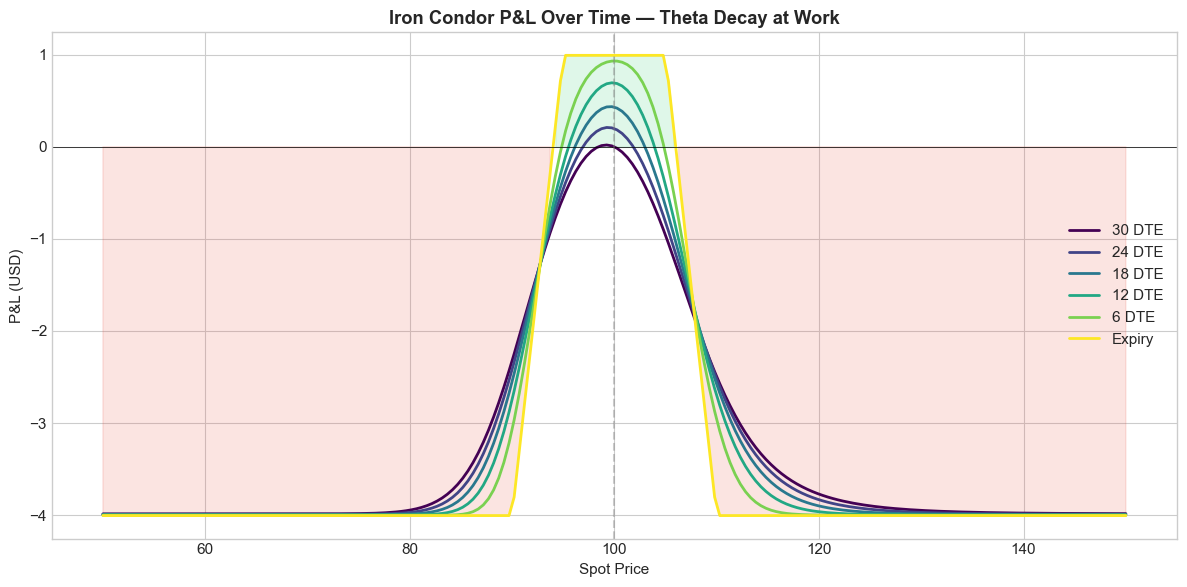

As DTE decreases, the P&L curve converges toward the expiry payoff.
At 30 DTE, the curve is smooth — time value dominates.
At expiry, it snaps to the hockey-stick intrinsic value.


In [9]:
# P&L surface for an iron condor
strat = iron_condor(90, 95, 105, 110, T_30d)
surface = compute_pnl_surface(strat, S, r, q, smile, n_S=200, n_t=6)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(surface.t_range)))

for i, (t_val, color) in enumerate(zip(surface.t_range, colors)):
    dte = (T_30d - t_val) * 365
    label = f"{dte:.0f} DTE" if dte > 0.5 else "Expiry"
    ax.plot(surface.S_range, surface.pnl_grid[i], linewidth=2, color=color, label=label)

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(S, color="gray", linestyle="--", alpha=0.4)
ax.fill_between(surface.S_range, surface.pnl_grid[-1], 0,
                where=surface.pnl_grid[-1] > 0, color="#2ecc71", alpha=0.15)
ax.fill_between(surface.S_range, surface.pnl_grid[-1], 0,
                where=surface.pnl_grid[-1] < 0, color="#e74c3c", alpha=0.15)
ax.set_xlabel("Spot Price")
ax.set_ylabel("P&L (USD)")
ax.set_title("Iron Condor P&L Over Time — Theta Decay at Work", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("As DTE decreases, the P&L curve converges toward the expiry payoff.")
print("At 30 DTE, the curve is smooth — time value dominates.")
print("At expiry, it snaps to the hockey-stick intrinsic value.")

---
## 7. Monte Carlo Simulation

### GBM with Student-t Innovations

Standard Monte Carlo uses Gaussian returns, which underestimate tail events. This engine replaces Normal innovations with **Student-t** distributed shocks:

$$S_T = S \exp\!\left[\left(r - q - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\, Z\right]$$

where $Z \sim t(\nu)$ scaled to unit variance: $Z = Z_{\text{raw}} \cdot \sqrt{(\nu - 2)/\nu}$.

| $\nu$ | Tail behavior | Use case |
|-------|---------------|----------|
| 30 | Near-Gaussian | Benign regime |
| 5 | Moderate fat tails | Typical equity |
| 3 | Heavy tails | Stress test |

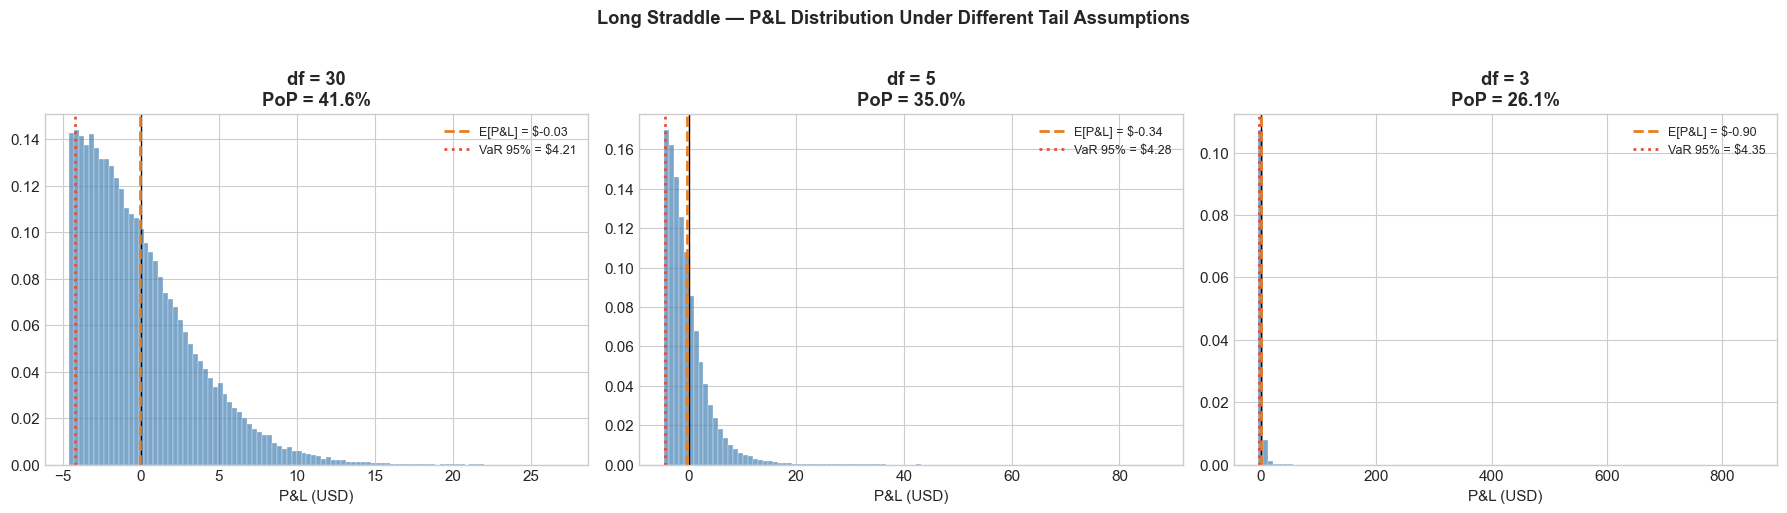

In [10]:
# Simulate a long straddle under different tail assumptions
strat = straddle(100, T_30d)
smile = VolSmile.from_simple(0.20, skew=0.4, curvature=0.5)

df_values = [30, 5, 3]
results = {}
for df in df_values:
    results[df] = simulate_strategy(strat, S, r, q, smile, n_paths=100_000, df=df, seed=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, df in zip(axes, df_values):
    sim = results[df]
    ax.hist(sim.pnl_samples, bins=100, density=True, alpha=0.7,
            color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(sim.expected_pnl, color="#e67e22", linewidth=2, linestyle="--",
               label=f"E[P&L] = ${sim.expected_pnl:.2f}")
    ax.axvline(-sim.var_95, color="#e74c3c", linewidth=2, linestyle=":",
               label=f"VaR 95% = ${sim.var_95:.2f}")
    ax.set_title(f"df = {df}\nPoP = {sim.prob_profit:.1%}", fontweight="bold")
    ax.set_xlabel("P&L (USD)")
    ax.legend(fontsize=9)

fig.suptitle("Long Straddle — P&L Distribution Under Different Tail Assumptions",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
# Risk metrics comparison table
rows = []
for df in df_values:
    sim = results[df]
    rows.append({
        "df (tails)": f"{df} ({'Near-Normal' if df >= 30 else 'Moderate' if df >= 5 else 'Heavy'})",
        "Prob of Profit": f"{sim.prob_profit:.1%}",
        "E[P&L]": f"${sim.expected_pnl:.2f}",
        "Median P&L": f"${sim.median_pnl:.2f}",
        "VaR 95%": f"${sim.var_95:.2f}",
        "CVaR 95%": f"${sim.cvar_95:.2f}",
        "VaR 99%": f"${sim.var_99:.2f}",
        "CVaR 99%": f"${sim.cvar_99:.2f}",
    })

df_risk = pd.DataFrame(rows)
display(df_risk)

print("\nWith heavier tails (lower df), the long straddle benefits:")
print("- Higher probability of large moves means more extreme payoffs")
print("- Expected P&L increases because large moves generate outsized gains")
print("- For short-vol strategies, the opposite holds — tail risk is the killer")

,df (tails),Prob of Profit,E[P&L],Median P&L,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
0,30 (Near-Normal),41.6%,$-0.03,$-0.79,$4.21,$4.39,$4.50,$4.53
1,5 (Moderate),35.0%,$-0.34,$-1.36,$4.28,$4.42,$4.51,$4.54
2,3 (Heavy),26.1%,$-0.90,$-2.04,$4.35,$4.46,$4.52,$4.55



With heavier tails (lower df), the long straddle benefits:
- Higher probability of large moves means more extreme payoffs
- Expected P&L increases because large moves generate outsized gains
- For short-vol strategies, the opposite holds — tail risk is the killer


---
## 8. VRP Strategy Comparison

The **Variance Risk Premium** (VRP) is the observation that implied vol systematically exceeds realized vol — making short-vol strategies profitable on average, but vulnerable to tail events.

We compare three ways to harvest VRP:

| Strategy | Structure | Tail risk |
|----------|-----------|----------|
| **Short Straddle** | Sell ATM call + put | Unlimited |
| **Iron Butterfly** | Short straddle + long symmetric wings | Capped at wing width |
| **Broken-Wing Butterfly** | Iron butterfly with wider put wing | Asymmetric — more downside protection |

In [12]:
# Build the three strategies
K = 100.0
T_vrp = 30 / 365
wing = 0.07  # 7% wing width

short_strad = Strategy(legs=[
    OptionLeg("call", "short", K, T_vrp),
    OptionLeg("put", "short", K, T_vrp),
])

iron_bf = Strategy(legs=[
    OptionLeg("call", "short", K, T_vrp),
    OptionLeg("put", "short", K, T_vrp),
    OptionLeg("call", "long", K * (1 + wing), T_vrp),
    OptionLeg("put", "long", K * (1 - wing), T_vrp),
])

bwb = Strategy(legs=[
    OptionLeg("call", "short", K, T_vrp),
    OptionLeg("put", "short", K, T_vrp),
    OptionLeg("call", "long", K * (1 + wing), T_vrp),
    OptionLeg("put", "long", K * (1 - wing * 1.5), T_vrp),  # wider put wing
])

vrp_strats = {
    "Short Straddle": short_strad,
    "Iron Butterfly": iron_bf,
    "Broken-Wing BF": bwb,
}

smile = VolSmile.from_simple(0.20, skew=0.4, curvature=0.5)

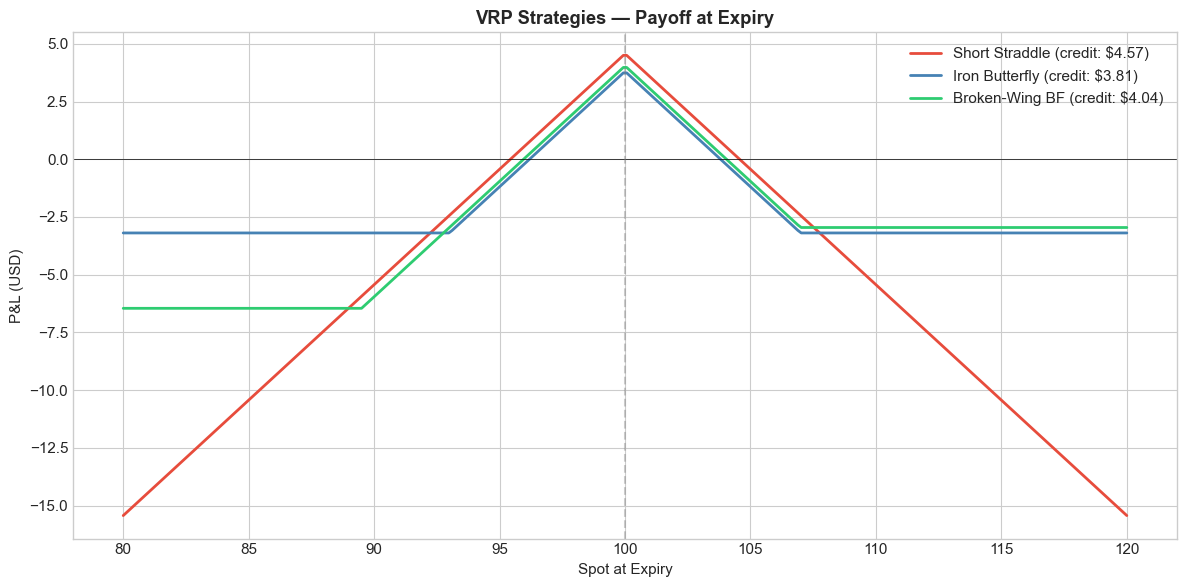

In [13]:
# Payoff overlay
S_range = np.linspace(80, 120, 300)
colors_vrp = ["#e74c3c", "steelblue", "#2ecc71"]

fig, ax = plt.subplots(figsize=(12, 6))

for (name, strat), color in zip(vrp_strats.items(), colors_vrp):
    cost = strat.compute_entry_cost(S, r, q, smile)
    payoff = strat.compute_payoff(S_range)
    pnl = payoff - cost
    ax.plot(S_range, pnl, linewidth=2, color=color, label=f"{name} (credit: ${-cost:.2f})")

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(S, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel("Spot at Expiry")
ax.set_ylabel("P&L (USD)")
ax.set_title("VRP Strategies — Payoff at Expiry", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

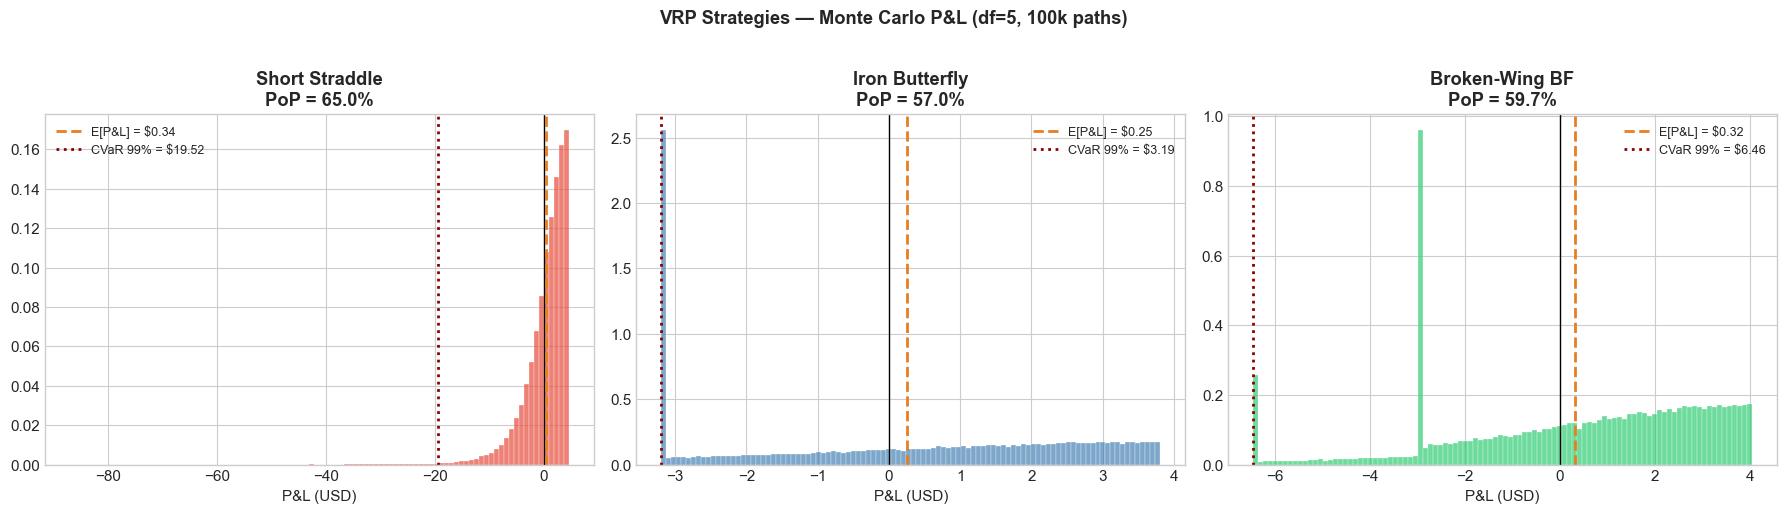

In [14]:
# Monte Carlo comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
mc_results = {}

for (name, strat), ax, color in zip(vrp_strats.items(), axes, colors_vrp):
    sim = simulate_strategy(strat, S, r, q, smile, n_paths=100_000, df=5, seed=42)
    mc_results[name] = sim

    ax.hist(sim.pnl_samples, bins=100, density=True, alpha=0.7,
            color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", linewidth=1)
    ax.axvline(sim.expected_pnl, color="#e67e22", linewidth=2, linestyle="--",
               label=f"E[P&L] = ${sim.expected_pnl:.2f}")
    ax.axvline(-sim.cvar_99, color="darkred", linewidth=2, linestyle=":",
               label=f"CVaR 99% = ${sim.cvar_99:.2f}")
    ax.set_title(f"{name}\nPoP = {sim.prob_profit:.1%}", fontweight="bold")
    ax.set_xlabel("P&L (USD)")
    ax.legend(fontsize=9)

fig.suptitle("VRP Strategies — Monte Carlo P&L (df=5, 100k paths)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Summary comparison table
rows = []
for name, strat in vrp_strats.items():
    sim = mc_results[name]
    g = compute_portfolio_greeks(strat, S, r, q, smile)
    cost = strat.compute_entry_cost(S, r, q, smile)
    rows.append({
        "Strategy": name,
        "Credit": f"${-cost:.2f}",
        "Prob of Profit": f"{sim.prob_profit:.1%}",
        "E[P&L]": f"${sim.expected_pnl:.2f}",
        "VaR 95%": f"${sim.var_95:.2f}",
        "CVaR 99%": f"${sim.cvar_99:.2f}",
        "Delta": f"{g.delta:+.4f}",
        "Theta/day": f"${g.theta_daily:+.2f}",
        "Vega": f"{g.vega:+.4f}",
    })

df_summary = pd.DataFrame(rows)
display(df_summary)

,Strategy,Credit,Prob of Profit,E[P&L],VaR 95%,CVaR 99%,Delta,Theta/day,Vega
0,Short Straddle,$4.57,65.0%,$0.34,$6.89,$19.52,-0.0594,$+0.08,-22.7868
1,Iron Butterfly,$3.81,57.0%,$0.25,$3.19,$3.19,-0.0508,$+0.03,-10.9905
2,Broken-Wing BF,$4.04,59.7%,$0.32,$4.40,$6.46,+0.0162,$+0.04,-13.6155


---
## Summary

| Step | Method | Key insight |
|------|--------|-------------|
| Pricing | Black-Scholes with dividend yield | Vectorized, skew-aware — each leg gets its own IV from the smile |
| Vol smile | SVI parameterization | 3 sliders (ATM vol, skew, curvature) map to 5 SVI parameters |
| Strategy | Multi-leg composition | 9 presets + free-form builder; entry cost accounts for skew |
| Greeks | Analytical per leg, summed | 7 Greeks (delta through volga) with sign and quantity weighting |
| Payoff | Intrinsic value − entry cost | Breakeven detection via linear interpolation of zero crossings |
| Time decay | Full BS repricing at each DTE | Not linear interpolation — captures convexity of time value |
| Monte Carlo | GBM + Student-t innovations | df parameter controls tail fatness; VaR/CVaR for risk metrics |

### Extensions

- **Live data integration**: connect the smile to a calibrated SVI surface from market option chains (see the Vol Surface Calibrator app)
- **Early exercise**: American option pricing via PDE or binomial tree (see the PDE Option Pricer app)
- **Correlation**: multi-asset strategies with correlated underlyings
- **Transaction costs**: bid-ask spread and commission impact on entry/exit